In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from scipy.special import erfcinv
import statsmodels.api as sm

In [19]:
def get_outliers_cooks(df):
    """
    Нахождение выбросов на основе расстояния Кука
    """
    # storing dependant values
    y = df.iloc[:, 1]

    # storing independent values
    x = df.iloc[:, 0]

    # add bias
    x = sm.add_constant(x)

    # create and train linear regression model
    sm_model = sm.regression.linear_model.OLS(y, x).fit()
    influence = sm_model.get_influence()

    influence_list = influence.cooks_distance[0]
    influence_df = pd.DataFrame(influence_list, columns=["influence"], index=df.index)

    original_length = len(df)

    cooks_df = df.join(influence_df)
    cooks_threshold = 4 / original_length
    cooks_outliers = cooks_df[cooks_df["influence"] > cooks_threshold]

    return set(cooks_outliers.index)

In [26]:
df = df[[k1, p1]]

In [27]:
out = get_outliers_cooks(df.dropna())

df_drop_out = df[~df.index.isin(out)]

df_drop_out = df_drop_out.dropna()

In [28]:
df_drop_out

,"Multisyllabic speech without HA in quiet FF, %","Predicted Multisyllabic speech without HA in quiet FF, %"
314,76.0,88.033971
315,61.0,87.509312
316,76.0,85.335721
317,94.0,99.250695
318,97.0,94.236273
319,97.0,96.324284
320,46.0,80.124197
321,35.0,69.894954
322,85.0,90.370352
323,82.0,89.758299


In [55]:
df = pd.read_csv('../data/result.csv')

In [7]:
k1 = 'Multisyllabic speech without HA in quiet FF, %' 
k2 = 'Multisyllabic speech with HA in quiet FF, %'
p1 = 'Predicted Multisyllabic speech without HA in quiet FF, %' 
p2 = 'Predicted Multisyllabic speech with HA in quiet FF, %'

In [29]:
b, a = np.polyfit(df_drop_out[k1], df_drop_out[p1], deg=1)

In [33]:
yn = np.poly1d([b, a])

In [40]:
df_drop_out

,"Multisyllabic speech without HA in quiet FF, %","Predicted Multisyllabic speech without HA in quiet FF, %"
314,76.0,88.033971
315,61.0,87.509312
316,76.0,85.335721
317,94.0,99.250695
318,97.0,94.236273
319,97.0,96.324284
320,46.0,80.124197
321,35.0,69.894954
322,85.0,90.370352
323,82.0,89.758299


In [44]:
df_drop_out['predict_lin'] = yn(df_drop_out[k1])

In [31]:
xseq = np.linspace(df[p1].min()-5, df[p1].max()+5, num=100)

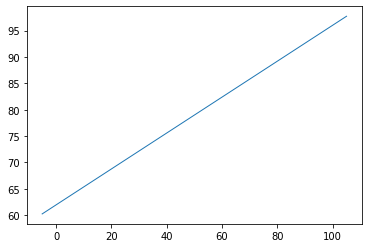

In [32]:
plt.plot(xseq, a + b * xseq, lw=1)

In [46]:
df_drop_out['error'] = df_drop_out[p1] - df_drop_out['predict_lin']

<AxesSubplot:>

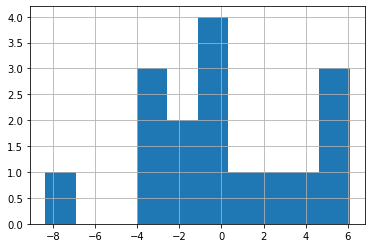

In [47]:
df_drop_out['error'].hist()

In [48]:
cols = [k2, p2]
color_dict = {k2: 'tab:blue', p2: 'tab:orange'}

In [59]:
column_name1 = 'Multisyllabic speech without HA in quiet FF, %' 
column_name2 = 'Multisyllabic speech with HA in quiet FF, %'

In [60]:
column_name1_pred = 'Predicted ' + column_name1
column_name2_pred = 'Predicted ' + column_name2

In [61]:
df1 = df[[column_name1, column_name1_pred]]
df2 = df[[column_name2, column_name2_pred]]

In [62]:
out = get_outliers_cooks(df1.dropna())

df_drop_out1 = df1[~df1.index.isin(out)]

df_drop_out1 = df_drop_out1.dropna()
df_drop_out1

,"Multisyllabic speech without HA in quiet FF, %","Predicted Multisyllabic speech without HA in quiet FF, %"
314,76.0,88.033971
315,61.0,87.509312
316,76.0,85.335721
317,94.0,99.250695
318,97.0,94.236273
319,97.0,96.324284
320,46.0,80.124197
321,35.0,69.894954
322,85.0,90.370352
323,82.0,89.758299


In [65]:
out = get_outliers_cooks(df2.dropna())

df_drop_out2 = df2[~df2.index.isin(out)]

df_drop_out2 = df_drop_out2.dropna()
df_drop_out2

,"Multisyllabic speech with HA in quiet FF, %","Predicted Multisyllabic speech with HA in quiet FF, %"
292,100.0,73.659084
293,100.0,84.578659
294,100.0,78.127030
295,100.0,52.068447
296,100.0,78.621079
297,100.0,82.937605
298,100.0,72.857986
299,100.0,65.904424
300,100.0,71.597484
301,100.0,76.275900


In [ ]:
b, a = np.polyfit(df_drop_out[k1], df_drop_out[p1], deg=1)

In [ ]:
# k1 = 'Multisyllabic speech without HA in quiet FF, %' 
# k2 = 'Multisyllabic speech with HA in quiet FF, %'
# p1 = 'Predicted Multisyllabic speech without HA in quiet FF, %' 
# p2 = 'Predicted Multisyllabic speech with HA in quiet FF, %'

In [ ]:
col = ['Error ' + column_name1, 'Error ' + column_name2]

In [50]:
def plot_kde(df, cols, figure_name='error.svg'):
    color_list =  ['tab:blue','tab:orange']
    fig, ax = plt.subplots(figsize=(8, 6))

    for num, col in enumerate(cols):
#         sns.histplot(data=df, x=col, label=col, ax=ax, kde_kws = {'bw_adjust': 0.5}, color=color_list[num])
        sns.kdeplot(data=df, x=col, label=col, ax=ax)

        kdeline = ax.lines[num]
        mean = df[col].mean()
        xs = kdeline.get_xdata()
        ys = kdeline.get_ydata()
        height = np.interp(mean, xs, ys)
        ax.vlines(mean, 0, height, color=color_list[num], ls=':')
        ax.fill_between(xs, 0, ys, facecolor=color_list[num], alpha=0.2)

    plt.legend()
    plt.grid()
    plt.xlabel('')
    plt.savefig(figure_name, format='svg', dpi=1200)

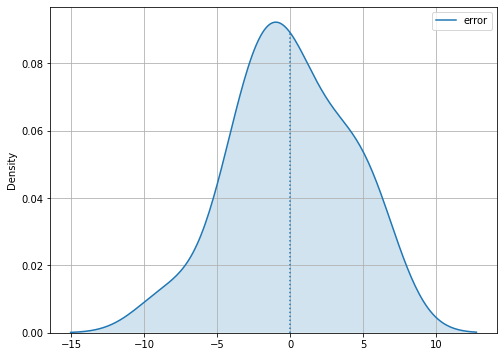

In [52]:
plot_kde(df_drop_out, ['error'])